In [2]:
import json
import os
import pathlib
import sys

import IPython.display
import matplotlib.patches
import matplotlib.pyplot
import numpy
import pandas


JSON2CBOR_EVAL_DIR = pathlib.Path.cwd()
os.environ["JSON2CBOR_EVAL_DIR"] = str(JSON2CBOR_EVAL_DIR)

if str((JSON2CBOR_EVAL_DIR / "..").absolute()) not in sys.path:
    sys.path.append(str((JSON2CBOR_EVAL_DIR / "..").absolute()))

from utils import list_code

This does not work in the VM (unless you install X or Wayland) so run it on your host.

In [2]:
%%bash

# Lighthouse needs at least Node 18, so use nvm to install the current stable
export NVM_DIR="${JSON2CBOR_EVAL_DIR}/.nvm"

if ! [ -d "${NVM_DIR}" ]; then
    git clone https://github.com/nvm-sh/nvm.git "${NVM_DIR}"
    cd "${NVM_DIR}"
    git checkout $(git describe --abbrev=0 --tags --match "v[0-9]*" $(git rev-list --tags --max-count=1))
fi

\. "${NVM_DIR}/nvm.sh"

nvm ls 23.4.0 || nvm install 23.4.0 && nvm use 23.4.0

npm install -g lighthouse

->      v23.4.0
Now using node v23.4.0 (npm v10.9.2)

changed 164 packages in 3s

11 packages are looking for funding
  run `npm fund` for details


In [3]:
%%bash

export NVM_DIR="${JSON2CBOR_EVAL_DIR}/.nvm"
\. "${NVM_DIR}/nvm.sh"

nvm use 23.4.0

OUTPUT_DIR="${JSON2CBOR_EVAL_DIR}/lighthouse-runs"
RUNS=100

mkdir -p "${OUTPUT_DIR}"

while [ "$( ls "${OUTPUT_DIR}" | wc -l )" -lt "${RUNS}" ]; do
    run_dir="${OUTPUT_DIR}/lighthouse-run-$(date "+%s")"
    mkdir -p "${run_dir}"
    lighthouse \
        -A "${run_dir}" -G "${run_dir}" \
        --quiet --output "csv" --output-path "${run_dir}/lhr.report.csv" \
        --disable-full-page-screenshot \
        --only-audits --preset=desktop --screenEmulation.width=1920 --screenEmulation.height=1080 \
        --throttling.rttMs=100 --throttling.uploadThroughputKbps 20480 --throttling.downloadThroughputKbps 51200 \
        https://www.zeit.de/index || rm -rf "${run_dir}"
    if "${JSON2CBOR_EVAL_DIR}/02_lighthouse_download_artifacts.py" "${run_dir}"; then
        COUNT=$((COUNT + 1))
    else
        rm -rf "${run_dir}"
    fi
done

Now using node v23.4.0 (npm v10.9.2)


Traceback (most recent call last):
  File "/home/mlenders/Repositories/PIVOT/cbor-dns-eval-clean/03_json2cbor_eval/02_lighthouse_download_artifacts.py", line 59, in <module>
    assert len(output) == item["resourceSize"], (
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: text/html:https://www.zeit.de/index: 1378143 != 1378387
Traceback (most recent call last):
  File "/home/mlenders/Repositories/PIVOT/cbor-dns-eval-clean/03_json2cbor_eval/02_lighthouse_download_artifacts.py", line 59, in <module>
    assert len(output) == item["resourceSize"], (
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: text/html:https://www.zeit.de/index: 1377467 != 1378143
Traceback (most recent call last):
  File "/home/mlenders/Repositories/PIVOT/cbor-dns-eval-clean/03_json2cbor_eval/02_lighthouse_download_artifacts.py", line 59, in <module>
    assert len(output) == item["resourceSize"], (
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: text/html:https://www.zeit.

# Create Database of Indexes for HTML Tags/Attributes and CSS Idents

In [4]:
list_code(JSON2CBOR_EVAL_DIR / "web_to_cbor.sql")

PRAGMA journal_mode = WAL;
PRAGMA foreign_keys = ON;
CREATE TABLE IF NOT EXISTS keys (
    id INTEGER PRIMARY KEY,
    type TEXT NOT NULL,
    key TEXT NOT NULL,
    count INTEGER NOT NULL
);
CREATE TABLE IF NOT EXISTS special_values (
    id INTEGER PRIMARY KEY,
    key_id INTEGER NOT NULL,
    value TEXT NOT NULL,
    count INTEGER NOT NULL,
    FOREIGN KEY (key_id)
       REFERENCES keys (id)
);

In [5]:
%%bash

DATABASE="${JSON2CBOR_EVAL_DIR}/idxs/lighthouse-runs.db"

rm -f "${DATABASE}"*
sqlite3 -batch "${DATABASE}" < "${JSON2CBOR_EVAL_DIR}"/web_to_cbor.sql

wal


In [6]:
list_code(JSON2CBOR_EVAL_DIR / "web_to_cbor.py")

#! /usr/bin/env python3
#
# Copyright (C) 2024 Martine S. Lenders <martine.lenders@tu-dresden.de>
#
# Distributed under terms of the MIT license.

## Copied on 2024-12-16 from mobi6, 06_discussion.


import argparse
import collections
import json
import pathlib
import re
import sqlite3
import sys
import traceback
import warnings

import bs4
import cbor2
import json5
import tinycss2


SCRIPT_PATH = pathlib.Path(__file__).parent

KEYS = {}
SPECIAL_VALUES = {}


def update_stats(typ, key, value=None):
    if typ not in KEYS:
        KEYS[typ] = {}
    if key in KEYS[typ]:
        KEYS[typ][key] += 1
    else:
        KEYS[typ][key] = 1
    if value is not None:
        if typ not in SPECIAL_VALUES:
            SPECIAL_VALUES[typ] = {}
        if key in SPECIAL_VALUES[typ]:
            if value in SPECIAL_VALUES[typ][key]:
                SPECIAL_VALUES[typ][key][value] += 1
            else:
                SPECIAL_VALUES[typ][key][value] = 1
        else:
            try:
                SPECIAL_VALUES[typ][key] = {value: 1}
            except TypeError:
                print(typ, key, value)


def add_navigable_string(name, content):
    if re.match(r"^\s*$", content) and name not in [
        "!-- COMMENT",
        "!CDATA",
        "!DOCTYPE",
    ]:
        # content only white spaces so effectively empty
        return {}
    if name != "str":
        update_stats("html", "NAME", name)
        update_stats("html", "CONTENT")
    return {"NAME": name, "CONTENT": [content]}


def xml_child_to_dict(elem):
    tag = {}
    if isinstance(elem, bs4.Declaration):
        tag = add_navigable_string("?xml", elem.string)
    elif isinstance(elem, bs4.ProcessingInstruction):
        tag = add_navigable_string("?PI", elem.string)
    elif isinstance(elem, bs4.Doctype):
        tag = add_navigable_string("!DOCTYPE", elem.string)
    elif isinstance(elem, bs4.CData):
        tag = add_navigable_string("!CDATA", elem.string)
    elif isinstance(elem, bs4.Stylesheet):
        tag = add_navigable_string("<STYLESHEET", elem.string)
        css = tinycss2.parse_stylesheet(
            elem.string,
            skip_comments=True,
            skip_whitespace=True
        )
        assert css
        # add to CSS ident index
        css_to_dict(css)
    elif isinstance(elem, bs4.Script):
        tag = add_navigable_string("<SCRIPT", elem.string)
    elif isinstance(elem, bs4.Comment):
        tag = add_navigable_string("!-- COMMENT", elem.string)
    elif isinstance(elem, bs4.TemplateString):
        tag = add_navigable_string("<TEMPLATE", elem.string)
    elif isinstance(elem, bs4.NavigableString):
        if type(elem) != bs4.NavigableString:
            raise ValueError(f"Unknown element, {type(elem)}, {elem}")
        tag = add_navigable_string("str", elem.string)
    elif isinstance(elem, bs4.Tag):
        children = xml_children_to_dicts(elem)

        tag = {
            "NAME": elem.name.lower(),
        }
        update_stats("html", "NAME", elem.name.lower())
        if children:
            update_stats("html", "CONTENT")
            tag["CONTENT"] = children
        for key in elem.attrs:
            lower_key = key.lower()
            if lower_key in ["class", "id", "style", "accesskey"]:
                continue
            if lower_key in ["rel", "accept-charset"]:
                for value in elem.attrs[key]:
                    update_stats("html", lower_key, value)
            else:
                update_stats("html", lower_key, elem.attrs[key])
            tag[lower_key] = elem.attrs[key]
    else:
        raise ValueError(f"Unknown element, {type(elem)}, {elem}")
    return tag


def xml_children_to_dicts(parent):
    res = []
    for elem in parent.childGenerator():
        tag = xml_child_to_dict(elem)
        if tag:
            res.append(tag)
        elif type(elem) not in [bs4.Script, bs4.Stylesheet, bs4.TemplateString]:
            assert (
                type(elem) == bs4.NavigableString
            ), f"OK to skip?

In [7]:
%%bash

DATABASE="${JSON2CBOR_EVAL_DIR}/idxs/lighthouse-runs.db"
OUTPUT_DIR="${JSON2CBOR_EVAL_DIR}/lighthouse-runs"

for artifact in $(find "${OUTPUT_DIR}"/lighthouse-run-*/artifacts/ -type f \! -name '*.cbor' -a \! -name '*.csv'); do
    "${JSON2CBOR_EVAL_DIR}"/web_to_cbor.py --collect-index "${DATABASE}" "${artifact}" || exit 1
done

In [8]:
%%bash

DATABASE="${JSON2CBOR_EVAL_DIR}/idxs/lighthouse-runs.db"
OUTPUT_DIR="${JSON2CBOR_EVAL_DIR}/lighthouse-runs"

"${JSON2CBOR_EVAL_DIR}"/web_to_cbor.py --create-index "${DATABASE}"

In [9]:
%%bash

DATABASE="${JSON2CBOR_EVAL_DIR}/idxs/lighthouse-runs.db"
OUTPUT_DIR="${JSON2CBOR_EVAL_DIR}/lighthouse-runs"

for artifact in $(find "${OUTPUT_DIR}"/lighthouse-run-*/artifacts/ -type f \! -name '*.cbor' -a \! -name '*.csv'); do
    "${JSON2CBOR_EVAL_DIR}"/web_to_cbor.py "${artifact}" || exit 1
done

In [10]:
%%bash

OUTPUT_DIR="${JSON2CBOR_EVAL_DIR}/lighthouse-runs"

find "${OUTPUT_DIR}"/lighthouse-run-*/artifacts/ -type f \! -name '*.cbor' -a \! -name '*.csv' | wc -l
find "${OUTPUT_DIR}"/lighthouse-run-*/artifacts/ -type f -name '*.cbor' | wc -l

4721
4721


In [14]:
%%bash

OUTPUT_DIR="${JSON2CBOR_EVAL_DIR}/lighthouse-runs"

find "${OUTPUT_DIR}"/lighthouse-run-*/artifacts/ -name '*.csv' | cat -n | while read i csv; do
    if [ $i -eq 1 ]; then
        awk -F',' '\
          BEGIN {OFS=","} \
          NR == 1 { \
            for (i = 1; i <= NF; i++) { \
              if ($i == "resourceSize") { \
                printf "%s%s%s%s%s%s%s", "runId", OFS, $i, OFS, "actualSize", OFS, "cborSize" \
              } \
              else { \
                printf "%s", $i \
              } \
              if ( i != NF ) { \
                printf "%s", OFS \
              } \
              else { \
                printf "%s", ORS \
              } \
            } \
          }' "${csv}"
    fi
    run_id=$(echo "${csv}" | grep -oE "lighthouse-run-[0-9]+" | grep -oE '[0-9]+')
    dirname=$(dirname "${csv}")
    awk -F',' "NF != 8 { printf \"Unexpected number of fields (%s) in ${csv}\\n\", NF > \"/dev/stderr\"; exit 1 }" "${csv}" || break
    awk -F',' 'NR > 1 { print $1, $2, $3, $4, $5, $6, $7, $8 }' "${csv}" | while read -r url mime_type resource_size curl_size network_request_time network_end_time rendered_start_time filename; do
        filename="$(echo "${dirname}/${filename}" | tr -d '\r')"
        actual_size=$(stat -c "%s" "${filename}")
        cbor_size=$(stat -c "%s" "${filename}.cbor")
        echo "${url},${mime_type},${run_id},${resource_size},${actual_size},${cbor_size},${curl_size},${network_request_time},${network_end_time},${rendered_start_time},$(realpath --relative-to=${JSON2CBOR_EVAL_DIR} "${filename}")"
    done
done > "${OUTPUT_DIR}/summary.csv"

# Add non-CSS/HTML/JSON resources

In [148]:
OUTPUT_DIR = JSON2CBOR_EVAL_DIR / "lighthouse-runs"

df = pandas.read_csv(
    JSON2CBOR_EVAL_DIR / "lighthouse-runs" / "summary.csv",
    dtype={"actualSize": "Int32", "cborSize": "Int32", "curlSize": "Int32"}
)

import pprint

for root, dirs, files in OUTPUT_DIR.walk():
    for filename in files:
        if filename == "lhr.report.json":
            with open(root / filename) as json_file:
                obj = json.load(json_file)
            for item in obj["audits"]["network-requests"]["details"]["items"]:
                if not df["url"].str.contains(item["url"], regex=False).any():
                    item["runId"] = int(str(root).split("-")[-1])
                    df = pandas.concat(
                        [
                            df,
                            pandas.DataFrame([{k: v for k, v in item.items() if k in df.columns}])
                        ]
                    )

df = df.sort_values(["runId", "networkRequestTime"]).reset_index(drop=True)
df.loc[df["filename"].fillna("").str.endswith(".html"), ["mimeType"]] = "text/html"
df.loc[df["filename"].fillna("").str.endswith(".css"), ["mimeType"]] = "text/css"
df.loc[df["filename"].fillna("").str.endswith(".json"), ["mimeType"]] = "application/json"
df.to_csv(JSON2CBOR_EVAL_DIR / "lighthouse-runs" / "summary.csv", index=False)

#### [Zeit.de Page Load Times](plots/zeit-de-pageload-time-1734717977.pdf)

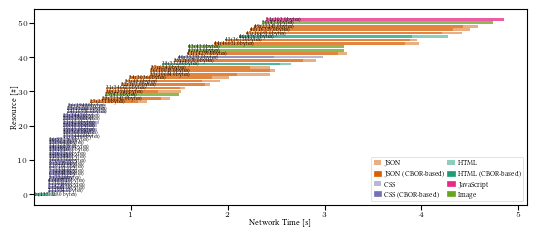

category
CSS           0.189207
HTML          0.663231
Image         0.000084
JSON          0.147428
JavaScript    0.000050
Name: resourceSize, dtype: float64

[48.0,
 231.0,
 302.0,
 654.0,
 1394.0,
 3036.0,
 3675.0,
 10018.0,
 10684.0,
 14299.0,
 16093.0,
 16359.0,
 26070.0,
 27145.0,
 46051.0,
 54602.0,
 72342.0]

0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           https://www.zeit.de/index
1                                                                                                                                                                                                                                                                 

In [7]:
MEDIA_TYPE_CATEGORY = {
    "application/font-woff": "Font",
    "application/javascript": "JavaScript",
    "application/json": "JSON",
    "application/x-javascript": "JavaScript",
    # "font/woff": "Font",
    # "font/woff2": "Font",
    "image/svg+xml": "Image",
    "image/gif": "Image",
    "image/webp": "Image",
    "text/css": "CSS",
    "text/html": "HTML",
    "text/javascript": "JavaScript",
}
CATEGORY_COLOR = {
    "HTML": "#1b9e77",
    "JSON": "#d95f02",
    "CSS": "#7570b3",
    "JavaScript": "#e7298a",
    "Image": "#66a61e",
    "Font": "#e6ab02",
    "Other": "#666666",
}
ORDER = {
    "JSON": 0,
    "JSON (CBOR-based)": 1,
    "CSS": 2,
    "CSS (CBOR-based)": 3,
    "HTML": 4,
    "HTML (CBOR-based)": 5,
    "JavaScript": 6,
    "Image": 7,
    "Font": 8,
    "Other": 9,
}
compressed_categories = ["JSON", "CSS", "HTML"]


def legend_without_duplicate_labels(ax):
    handles, labels = ax.get_legend_handles_labels()
    entries = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i] if l in compressed_categories]
    entries.extend(
        [(matplotlib.patches.Patch(color=CATEGORY_COLOR[l]), f"{l} (CBOR-based)") for i, l in enumerate(labels) if l not in labels[:i] if l in compressed_categories]
    )
    entries.extend(
        [(matplotlib.patches.Patch(color=CATEGORY_COLOR[l]), l) for i, l in enumerate(labels) if l not in labels[:i] if l not in compressed_categories]
    )
    entries.sort(key=lambda k: (ORDER.get(k[1], float("inf")), k[1]))
    ax.legend(*zip(*entries), loc="lower right", ncol=2)


df = pandas.read_csv(
    JSON2CBOR_EVAL_DIR / "lighthouse-runs" / "summary.csv",
    dtype={"actualSize": "Int32", "cborSize": "Int32", "curlSize": "Int32"},
)

df.loc[:, ["networkRequestTime", "networkEndTime", "rendererStartTime"]] /= 1000

for run_id in [1734717977]:
    matplotlib.pyplot.clf()
    matplotlib.style.use(JSON2CBOR_EVAL_DIR / ".." / "mlenders_fullwidth.mplstyle")
    matplotlib.rcParams["figure.figsize"] = (
        matplotlib.rcParams["figure.figsize"][0] * 1.16,
        matplotlib.rcParams["figure.figsize"][1] * 1.50,
    )
    diff = 0
    ax = matplotlib.pyplot.gca()
    stats = df[df["runId"] == run_id].groupby(["url"])[["networkRequestTime", "networkEndTime", "rendererStartTime", "resourceSize", "actualSize", "cborSize"]].mean().join(
    #    df[df["runId"] == run_id].groupby(["url"])[["networkRequestTime", "networkEndTime"]].std(),
    #    lsuffix="Mean",
    #    rsuffix="Std",
    #).join(
        df[df["runId"] == run_id].groupby("url")[["mimeType"]].agg(lambda x: x if x.count == 1 else list(x)[0])
    ).sort_values(["networkRequestTime"]).reset_index()
    stats["category"] = stats["mimeType"].apply(lambda t: MEDIA_TYPE_CATEGORY.get(t, "Other"))
    #stats.loc[stats["category"] == "HTML", ["cborNetworkEndTime"]] = stats["networkEndTime"] * (stats["cborSize"] / stats["actualSize"])
    #stats.loc[stats["category"] == "CSS", ["cborNetworkEndTime"]] = stats["networkEndTime"] * (stats["cborSize"] / stats["actualSize"])

    orig = stats.copy()
    # TODO: this needs to be based on actual data rate!
    stats.loc[stats["category"].isin(compressed_categories), ["networkEndTime"]] = stats["networkEndTime"] * (stats["cborSize"] / stats["actualSize"])
    prev_rstart_time = 0
    #for idx, row in stats.iterrows():
    #    if ((row["networkRequestTime"] - diff) > prev_rstart_time):
    #        stats.loc[idx, ["networkRequestTime", "networkEndTime", "rendererStartTime"]] -= diff
    #        if row["category"] in compressed_categories:
    #            print(orig.loc[idx, "networkEndTime"], row["networkEndTime"], orig.loc[idx, "networkEndTime"] - row["networkEndTime"])
    #            diff += (orig.loc[idx, "networkEndTime"] - row["networkEndTime"])
    #    prev_rstart_time = stats.loc[idx, "rendererStartTime"]
    ax.barh(
        range(orig.shape[0]),
        width=orig["networkEndTime"],
        left=orig["networkRequestTime"],
        color=[CATEGORY_COLOR[c] for c in orig["category"]],
        label=[c for c in orig["category"]],
        alpha=0.5,
    )
    ax.barh(
        range(stats.shape[0]),
        width=stats["networkEndTime"],
        left=stats["networkRequestTime"],
        color=[CATEGORY_COLOR[c] for c in stats["category"]],
        label=[c for c in stats["category"]],
        alpha=0.5,
    )
    for i in orig.index:      
        ax.text(
            orig.loc[i, "networkRequestTime"],
            i,
            f"{i} ({orig.loc[i, "resourceSize"]} bytes)",
            fontsize=4,
            va="center",
        )
    filepath = JSON2CBOR_EVAL_DIR / "plots" / f"zeit-de-pageload-time-{run_id}.pdf"
    IPython.display.display(
        IPython.display.Markdown(
            f"#### [Zeit.de Page Load Times]({str(filepath.relative_to(pathlib.Path.cwd()))})"
        )
    )
    legend_without_duplicate_labels(ax)
    #ax.set_xticks(numpy.arange(0.0, 0.2, 5))
    ax.set_ylabel(r"Resource [\#]")
    ax.set_xlabel(r"Network Time [s]")
    matplotlib.pyplot.savefig(filepath, bbox_inches="tight", pad_inches=0.01)
    matplotlib.pyplot.show()
#df[df["runId"] == 1734717977].sort_values(["networkRequestTime"]).reset_index(drop=True)[["networkRequestTime", "rendererStartTime"]] #runId.unique()
    IPython.display.display(
        orig.groupby("category")["resourceSize"].sum() /
        orig.groupby("category")["resourceSize"].sum().sum()
    )
    IPython.display.display(
        orig[orig["category"] == "JSON"]["resourceSize"].sort_values().to_list()
    )
    with pandas.option_context("display.max_colwidth", None):
        IPython.display.display(
            orig.url
        )